In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import numpy as np
import copy
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✔ Device: {device}')

✔ Device: cpu


In [2]:
NUM_CLIENTS   = 5
NUM_ROUNDS    = 10
LOCAL_EPOCHS  = 2
BATCH_SIZE    = 32
LEARNING_RATE = 0.001

TRAIN_SIZE    = 48000   # 80% → FL clients
VAL_SIZE      = 12000   # 20% → server validation
# Test = 10,000 (separate MNIST split, used only at the end)

print("Hyperparameters set ✔")

Hyperparameters set ✔


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download
full_train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train → training (for clients) + validation (for server)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(42)
)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('─' * 45)
print(f'  Training samples  (FL clients) : {len(train_dataset):>6}')
print(f'  Validation samples (server)    : {len(val_dataset):>6}')
print(f'  Test samples (final only)      : {len(test_dataset):>6}')
print('─' * 45)

100%|██████████| 9.91M/9.91M [00:00<00:00, 51.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.26MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]


─────────────────────────────────────────────
  Training samples  (FL clients) :  48000
  Validation samples (server)    :  12000
  Test samples (final only)      :  10000
─────────────────────────────────────────────


In [4]:
def split_data_iid(dataset, num_clients):
    indices    = np.random.permutation(len(dataset))
    chunk_size = len(dataset) // num_clients

    client_loaders = []
    for i in range(num_clients):
        client_indices   = indices[i * chunk_size : (i + 1) * chunk_size]
        original_indices = [dataset.indices[j] for j in client_indices]
        subset = Subset(dataset.dataset, original_indices)
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
        client_loaders.append(loader)

    return client_loaders

client_loaders = split_data_iid(train_dataset, NUM_CLIENTS)

print("Client data distribution (IID):")
for i, loader in enumerate(client_loaders):
    print(f'  Client {i+1}: {len(loader.dataset):,} samples')

Client data distribution (IID):
  Client 1: 9,600 samples
  Client 2: 9,600 samples
  Client 3: 9,600 samples
  Client 4: 9,600 samples
  Client 5: 9,600 samples


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1   = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1     = nn.Linear(64 * 7 * 7, 128)
        self.fc2     = nn.Linear(128, 10)   # 10 classes (digits 0–9)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

global_model = CNN().to(device)
print(global_model)
print(f'\nTotal parameters: {sum(p.numel() for p in global_model.parameters()):,}')

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


In [6]:
def local_train(global_weights, data_loader, epochs, lr):
    local_model = CNN().to(device)
    local_model.load_state_dict(copy.deepcopy(global_weights))
    local_model.train()

    optimizer = optim.Adam(local_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(local_model(images), labels)
            loss.backward()
            optimizer.step()

    return local_model.state_dict()


def fedavg(global_weights, client_weights_list):
    averaged = copy.deepcopy(client_weights_list[0])
    for key in averaged:
        for i in range(1, len(client_weights_list)):
            averaged[key] += client_weights_list[i][key]
        averaged[key] = torch.div(averaged[key], len(client_weights_list))
    return averaged


def evaluate(model, loader):
    model.eval()
    criterion  = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, 100.0 * correct / total

print("Helper functions ready ✔")

Helper functions ready ✔


In [8]:
history = {'round': [], 'val_loss': [], 'val_accuracy': []}

print('=' * 55)
print('      FEDERATED LEARNING TRAINING STARTED')
print('=' * 55)

for round_num in range(1, NUM_ROUNDS + 1):

    # Step 1: Get current global weights
    global_weights = global_model.state_dict()

    # Step 2: Each client trains locally
    client_weights = []
    for loader in client_loaders:
        updated = local_train(global_weights, loader, LOCAL_EPOCHS, LEARNING_RATE)
        client_weights.append(updated)

    # Step 3: Server aggregates with FedAvg
    aggregated = fedavg(global_weights, client_weights)
    global_model.load_state_dict(aggregated)

    # Step 4: Evaluate on validation set
    val_loss, val_acc = evaluate(global_model, val_loader)

    history['round'].append(round_num)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f'  Round {round_num:02d}/{NUM_ROUNDS}  |  Val Loss: {val_loss:.4f}  |  Val Acc: {val_acc:.2f}%')

print('=' * 55)
print('✅ Training Complete!')

      FEDERATED LEARNING TRAINING STARTED
  Round 01/10  |  Val Loss: 0.1406  |  Val Acc: 97.22%
  Round 02/10  |  Val Loss: 0.0494  |  Val Acc: 98.62%
  Round 03/10  |  Val Loss: 0.0393  |  Val Acc: 98.83%
  Round 04/10  |  Val Loss: 0.0376  |  Val Acc: 98.96%
  Round 05/10  |  Val Loss: 0.0339  |  Val Acc: 99.08%
  Round 06/10  |  Val Loss: 0.0325  |  Val Acc: 99.10%
  Round 07/10  |  Val Loss: 0.0321  |  Val Acc: 99.11%
  Round 08/10  |  Val Loss: 0.0319  |  Val Acc: 99.10%
  Round 09/10  |  Val Loss: 0.0321  |  Val Acc: 99.21%
  Round 10/10  |  Val Loss: 0.0302  |  Val Acc: 99.23%
✅ Training Complete!


In [9]:
test_loss, test_acc = evaluate(global_model, test_loader)

print('\n' + '═' * 40)
print('       FINAL TEST SET RESULTS')
print('═' * 40)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.2f}%')
print('═' * 40)


════════════════════════════════════════
       FINAL TEST SET RESULTS
════════════════════════════════════════
  Test Loss     : 0.0226
  Test Accuracy : 99.35%
════════════════════════════════════════


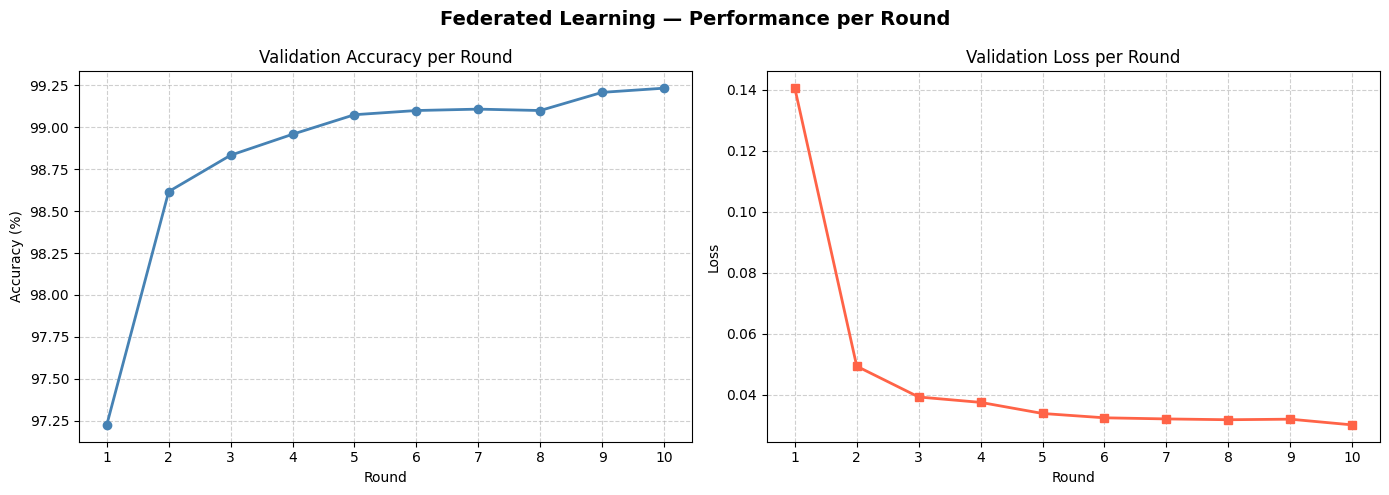

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Federated Learning — Performance per Round', fontsize=14, fontweight='bold')

rounds = history['round']

axes[0].plot(rounds, history['val_accuracy'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Validation Accuracy per Round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xticks(rounds)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(rounds, history['val_loss'], marker='s', color='tomato', linewidth=2)
axes[1].set_title('Validation Loss per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(rounds)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()